# Loading

In [15]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# single cell
import anndata as ad
import scanpy as sc

# custom
sys.path.insert(0, '../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

CORES = 10
HOMEDIR = Path("..") / ".." / ".."
DATADIR = HOMEDIR / "data"
MAIN_DIR = DATADIR
SUBSETS_DIR = MAIN_DIR / "subsets"

METADATA = [
    "Diet",
    "Age",
    "Depot",
    "Sex",
]
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
GLOBAL_INT_KEY = "global_INT_scvi-hvg-Identifier"

%load_ext autoreload
%load_ext rpy2.ipython
%matplotlib inline
converter = get_converter()
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Click 9.1. Use feature detection or 'importlib.metadata.version("click")' instead.
/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: Accessing jsonschema.__version__ is deprecated and will be removed in a future release. Use importlib.metadata directly to query for jsonschema's version.


In [52]:
CELLTYPE_ADDON = "adipo"
CLUSTER_KEY = "leiden_adipo"
DE_KEY = "adipo_DEGs"
# SELECT_RES = [0.4, 0.6]
INT_KEY = 'INT_harmony_global_PCA-hvg_Dataset'
contam_resolutions = np.arange(1, 6) / 5
resolutions = np.arange(1, 10) / 10

celltype_markers_concise = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5"],
    "Smooth Muscle Cell": ["Myocd"],
    "Pericyte": ["Enpep"],
    "Epithelial 1": ["Dcdc2a"],
    "Epithelial 2": ["Erbb4"],
    "Macrophage": ["Adgre1"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d"],
    "NK Cell": ["Klrd1"],
}

celltype_markers_full = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra", "Col1a1"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5", "Cldn5"],
    "Smooth Muscle Cell": ["Myocd", "Myh11"],
    "Pericyte": ["Enpep", "Pdgfrb"],
    "Epithelial": ["Dcdc2a", "Erbb4", "Epcam"],
    "Macrophage": ["Adgre1", "Itgam"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r", "S100a8", "S100a9"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d", "Cd3e"],
    "NK Cell": ["Klrd1", "Ncr1"],
}

# Load Data

In [8]:
adata = sc.read_h5ad(MAIN_DIR / "eWAT_Male.h5ad")
# adata = ad.read_zarr(MAIN_DIR / "eWAT_Male.zarr")
print(adata.obs["celltype"].cat.categories, "\n")
adata

Index(['Adipocyte', 'Fibroblast', 'Mesothelial', 'Endothelial',
       'Smooth Muscle', 'Pericyte', 'Epithelial', 'Macrophage', 'Dendritic',
       'Mast Cell', 'Neutrophil', 'B Cell', 'T Cell', 'NK Cell'],
      dtype='object') 



AnnData object with n_obs × n_vars = 191104 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_

AnnData object with n_obs × n_vars = 20161 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_v

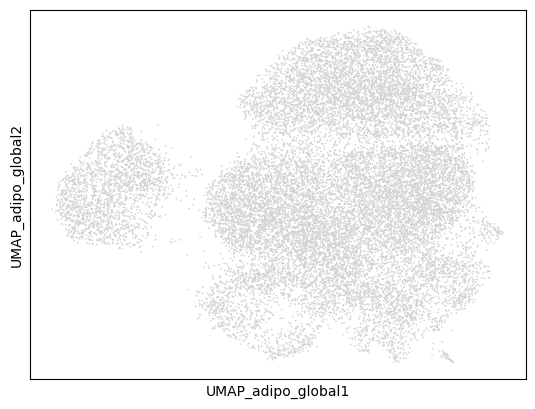

Running NN Backend on high-dimensional data. Nearest-neighbor search may be slow!


finished neighbors & UMAP in 0:01:02.894365


---------------------------------------------
begin LocalMAP at Thu Jul  9 11:00:12 2026, (total: 0:10:58.106542)



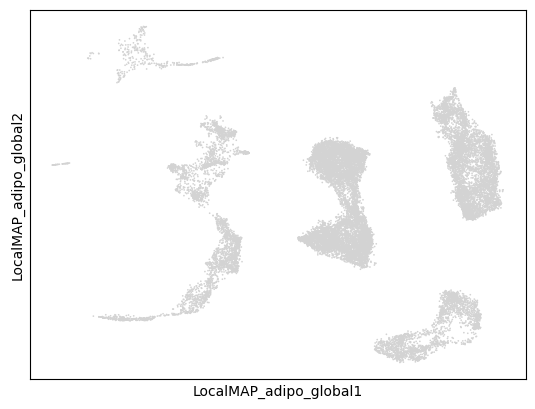

finished LocalMAP in 0:00:22.334642



AnnData object with n_obs × n_vars = 20161 × 22171
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_v

In [9]:
# subset
adata_adipo = adata[adata.obs["celltype"].isin(["Adipocyte"])].copy()
print(adata_adipo)
del adata_adipo.uns, adata_adipo.varm, adata_adipo.obsp
Filter_QC(adata_adipo)
Visualize(adata_adipo, key=f"{CELLTYPE_ADDON}_global", obsm=GLOBAL_INT_KEY)

# Integration check

found 6 groups in Dataset


Plotting individual Dataset: 100%|██████████| 6/6 [00:00<00:00, 13.80it/s]


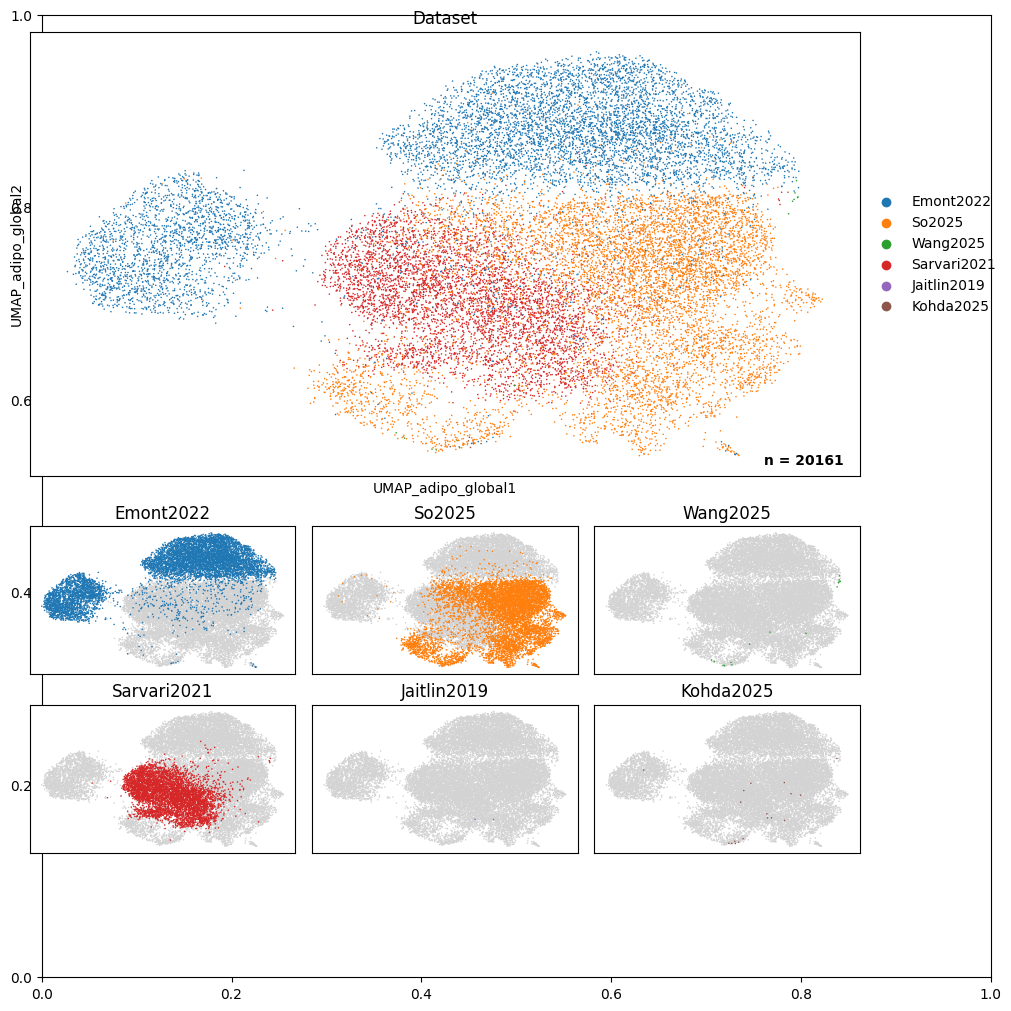

In [14]:
# sc.pl.embedding(adata_adipo, "UMAP_adipo_global", color='Dataset')

fig,ax = plt.subplots(1,1, figsize=(10,10), layout="constrained")
check_integration(adata_adipo, "Dataset", fig, ["UMAP_adipo_global"], nrow=3)

# Reintegration

In [44]:
# # print current layer in adata.X
# print(adata_adipo.X[:10,:10].toarray())

# # change layer from adata.layers
# print(adata_adipo.layers["normalized"][:10,:10].toarray())

adata_adipo.X = adata_adipo.layers["normalized"].copy()
FindVariableGenes(adata_adipo, "seurat_v3", n_features=1000)
PCA(adata_adipo, gene_mask="highly_variable", key="PCA_adipo")
Integrate(adata_adipo, "Dataset", pca_key="global_PCA-hvg",integration_key="INT_harmony_global_PCA-hvg_Dataset")

Finding HVGs...
Setting layer to normalized.
Starting PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA_adipo].


2026-07-09 12:03:32,259 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
Running Harmony (PyTorch on cpu)
2026-07-09 12:03:32,261 - harmonypy - INFO -   Parameters:
  Parameters:
2026-07-09 12:03:32,262 - harmonypy - INFO -     max_iter_harmony: 50
    max_iter_harmony: 50
2026-07-09 12:03:32,262 - harmonypy - INFO -     max_iter_kmeans: 20
    max_iter_kmeans: 20
2026-07-09 12:03:32,263 - harmonypy - INFO -     epsilon_cluster: 1e-05
    epsilon_cluster: 1e-05
2026-07-09 12:03:32,264 - harmonypy - INFO -     epsilon_harmony: 0.0001
    epsilon_harmony: 0.0001
2026-07-09 12:03:32,265 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-07-09 12:03:32,266 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-07-09 12:03:32,267 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1.]
    lamb: [1. 1. 1. 1. 1. 1.]
2026-07-09 12:03:32,268 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
    theta: [2. 2. 2. 2. 2. 2.]
2026-07-09 12:03:32,269 - harmonypy - INFO -     sig


---------------------------------------------
begin Integration at Thu Jul  9 12:03:32 2026, (total: 1:14:17.629174)

Integrating by Column Dataset: ['Kohda2025', 'Jaitlin2019', 'Sarvari2021', 'Wang2025', 'So2025', 'Emont2022']
Categories (6, object): ['Emont2022', 'So2025', 'Wang2025', 'Sarvari2021', 'Jaitlin2019', 'Kohda2025']


2026-07-09 12:03:33,117 - harmonypy - INFO - KMeans initialization complete.
KMeans initialization complete.
2026-07-09 12:03:33,235 - harmonypy - INFO - Iteration 1 of 50
Iteration 1 of 50
2026-07-09 12:03:36,445 - harmonypy - INFO - Iteration 2 of 50
Iteration 2 of 50
2026-07-09 12:03:39,558 - harmonypy - INFO - Iteration 3 of 50
Iteration 3 of 50
2026-07-09 12:03:42,777 - harmonypy - INFO - Iteration 4 of 50
Iteration 4 of 50
2026-07-09 12:03:45,929 - harmonypy - INFO - Iteration 5 of 50
Iteration 5 of 50
2026-07-09 12:03:47,904 - harmonypy - INFO - Iteration 6 of 50
Iteration 6 of 50
2026-07-09 12:03:51,037 - harmonypy - INFO - Converged after 6 iterations
Converged after 6 iterations


finished Integration in 0:00:18.804108



AnnData object with n_obs × n_vars = 20161 × 22171
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_v

In [56]:
clear_obsm(adata_adipo, "global", filter=INT_KEY)
clear_obsm(adata_adipo, "UMAP_UMAP")
clear_obsm(adata_adipo, "LocalMAP_UMAP")
adata_adipo

deleted from `obsm`:  UMAP_UMAP_INT_harmony_global_PCA-hvg_Dataset
deleted from `obsm`:  LocalMAP_UMAP_INT_harmony_global_PCA-hvg_Dataset


AnnData object with n_obs × n_vars = 20161 × 22171
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_v


---------------------------------------------
begin neighbors & UMAP at Thu Jul  9 12:10:42 2026, (total: 1:21:28.078158)

Starting UMAP...


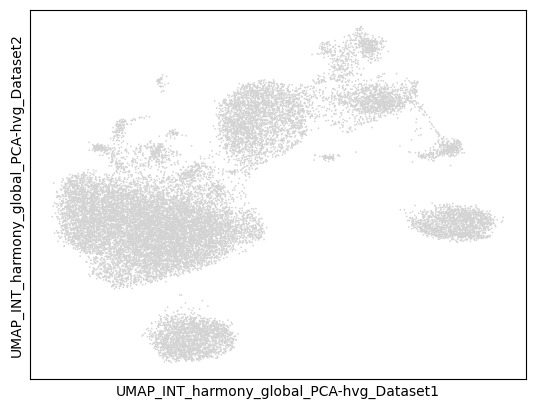

Running NN Backend on high-dimensional data. Nearest-neighbor search may be slow!


finished neighbors & UMAP in 0:00:17.823767


---------------------------------------------
begin LocalMAP at Thu Jul  9 12:11:00 2026, (total: 1:21:45.902221)



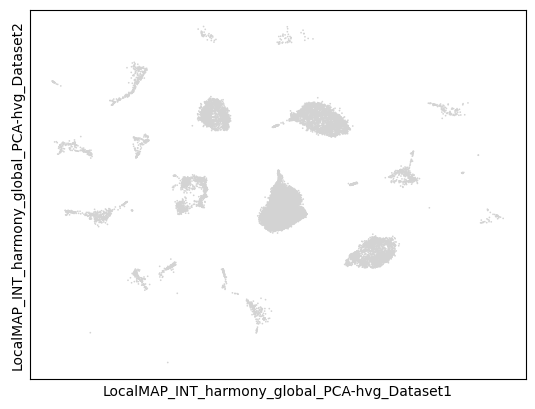

finished LocalMAP in 0:00:14.751738



AnnData object with n_obs × n_vars = 20161 × 22171
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_v

In [57]:
Visualize(adata_adipo, INT_KEY, INT_KEY)

found 6 groups in Dataset


Plotting individual Dataset: 100%|██████████| 6/6 [00:00<00:00, 17.82it/s]


found 2 groups in Diet
Palette not found! Generating palette.


Plotting individual Diet: 100%|██████████| 2/2 [00:00<00:00, 18.39it/s]


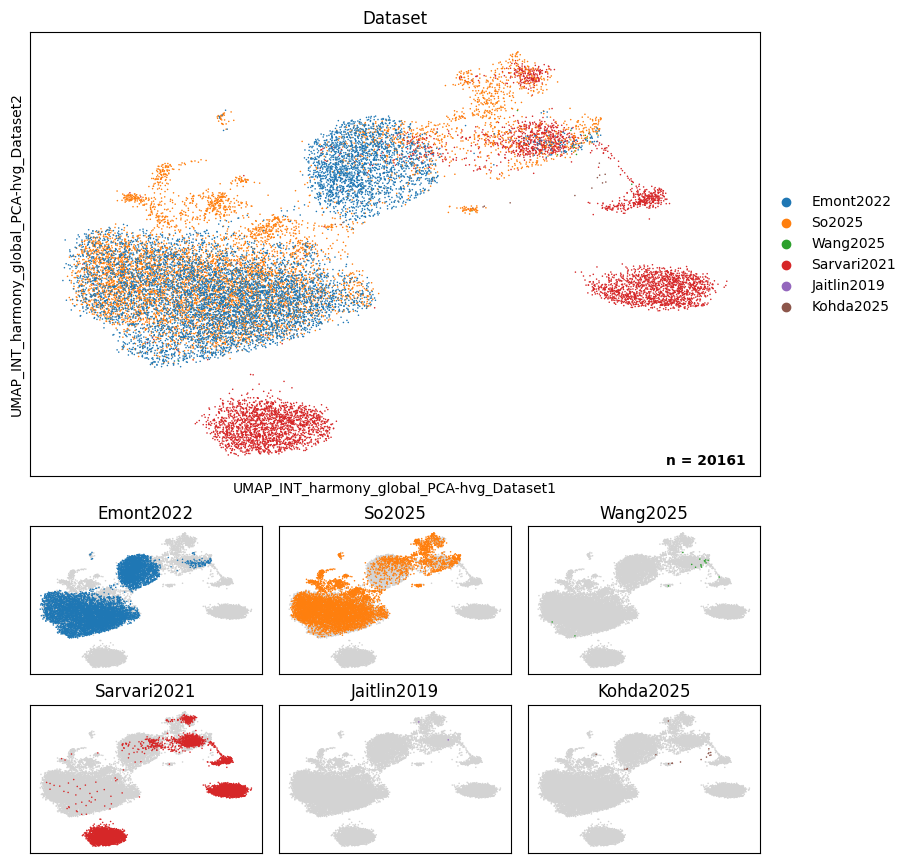

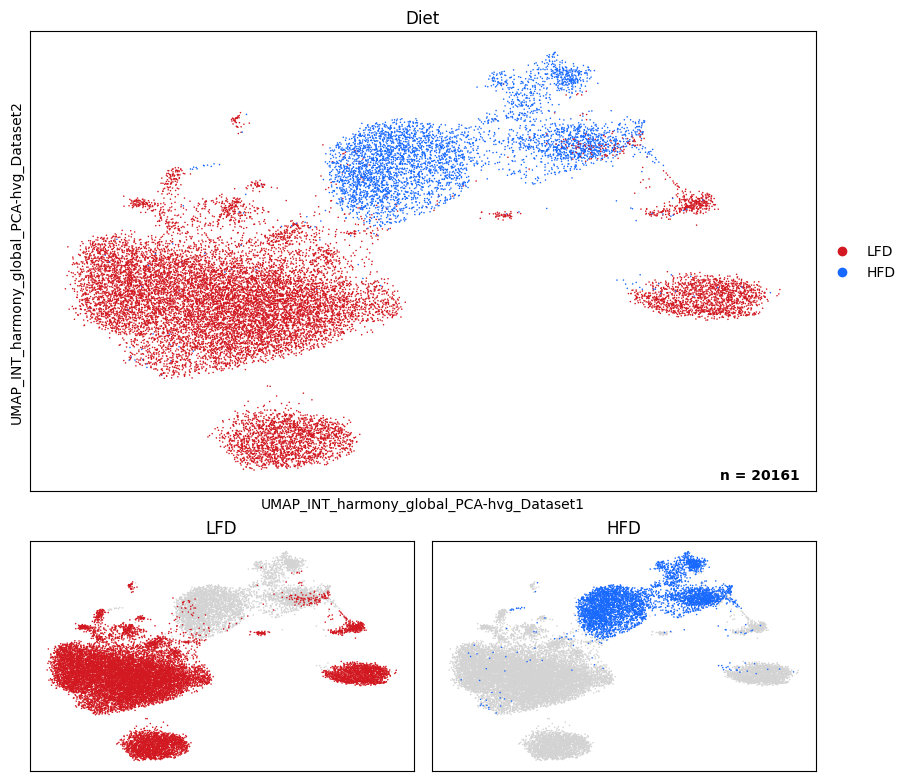

In [58]:
check_integration(
    adata_adipo, "Dataset",
    embeddings=[f"UMAP_{INT_KEY}"],
    f=plt.figure(figsize=(9,10), layout="constrained"),
    nrow=3)

check_integration(
    adata_adipo, "Diet",
    embeddings=[f"UMAP_{INT_KEY}"],
    f=plt.figure(figsize=(9,10), layout="constrained"),
    nrow=2)

### integration score checks

In [ ]:
%autoreload 2
# note: must recompile knngraph.o, from https://github.com/theislab/scib/issues/375

iLISI_scores = pd.Series(
    [
        scib.metrics.ilisi_graph(
        adata_adipo,
        "Dataset",
        "embed",
        use_rep=int_key,
        verbose=True)
        for int_key in tqdm(all_integrations)
    ],
    index = all_integrations
)
temp = adata_adipo.copy()
scib.pp.reduce_data(temp, "Dataset", neighbors=False, overwrite_hvg=False)

f, axs = plt.subplots(1,2,figsize=(20,7), layout="constrained")
sns.barplot(iLISI_scores, ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=40, ha="right")
axs[0].set_title("Integration LISI Scores")
axs[0].set_ylabel("iLISI score")
axs[0].set_xlabel("resolution")

In [ ]:
temp = adata_adipo.copy()
scib.pp.reduce_data(temp, "Dataset", neighbors=False, overwrite_hvg=False)

f, axs = plt.subplots(1,3,figsize=(30,10), layout="constrained")
axs = axs.flatten()

for i, covariate in enumerate(["Dataset", "Identifier", "Age"]):
    # compute scores (Series with index in the desired order)
    PRC_Comp_scores = pd.Series(
        [ scib.metrics.pcr_comparison(
            temp,
            temp,
            covariate=covariate,
            embed=int_key,
            verbose=False)
          for int_key in tqdm(all_integrations) ],
        index = all_integrations
    )

    ax = axs[i]
    # pass explicit x (categories) and y (values), and set order to keep index order
    sns.barplot(x=PRC_Comp_scores.index,
                y=PRC_Comp_scores.values,
                order=PRC_Comp_scores.index,
                ax=ax,
                errorbar=None)   # disable errorbars if not needed

    # get the BarContainer that seaborn created and label it
    bars = ax.containers[0]               # seaborn stores bars here
    ax.bar_label(bars, fmt='%.3f', padding=2)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_title(f"PCR Comparison Scores\n(covariate `{covariate}`)")
    ax.set_ylabel("Scaled Δ PCR Variance")
    ax.set_xlabel("resolution")

# Cleaning

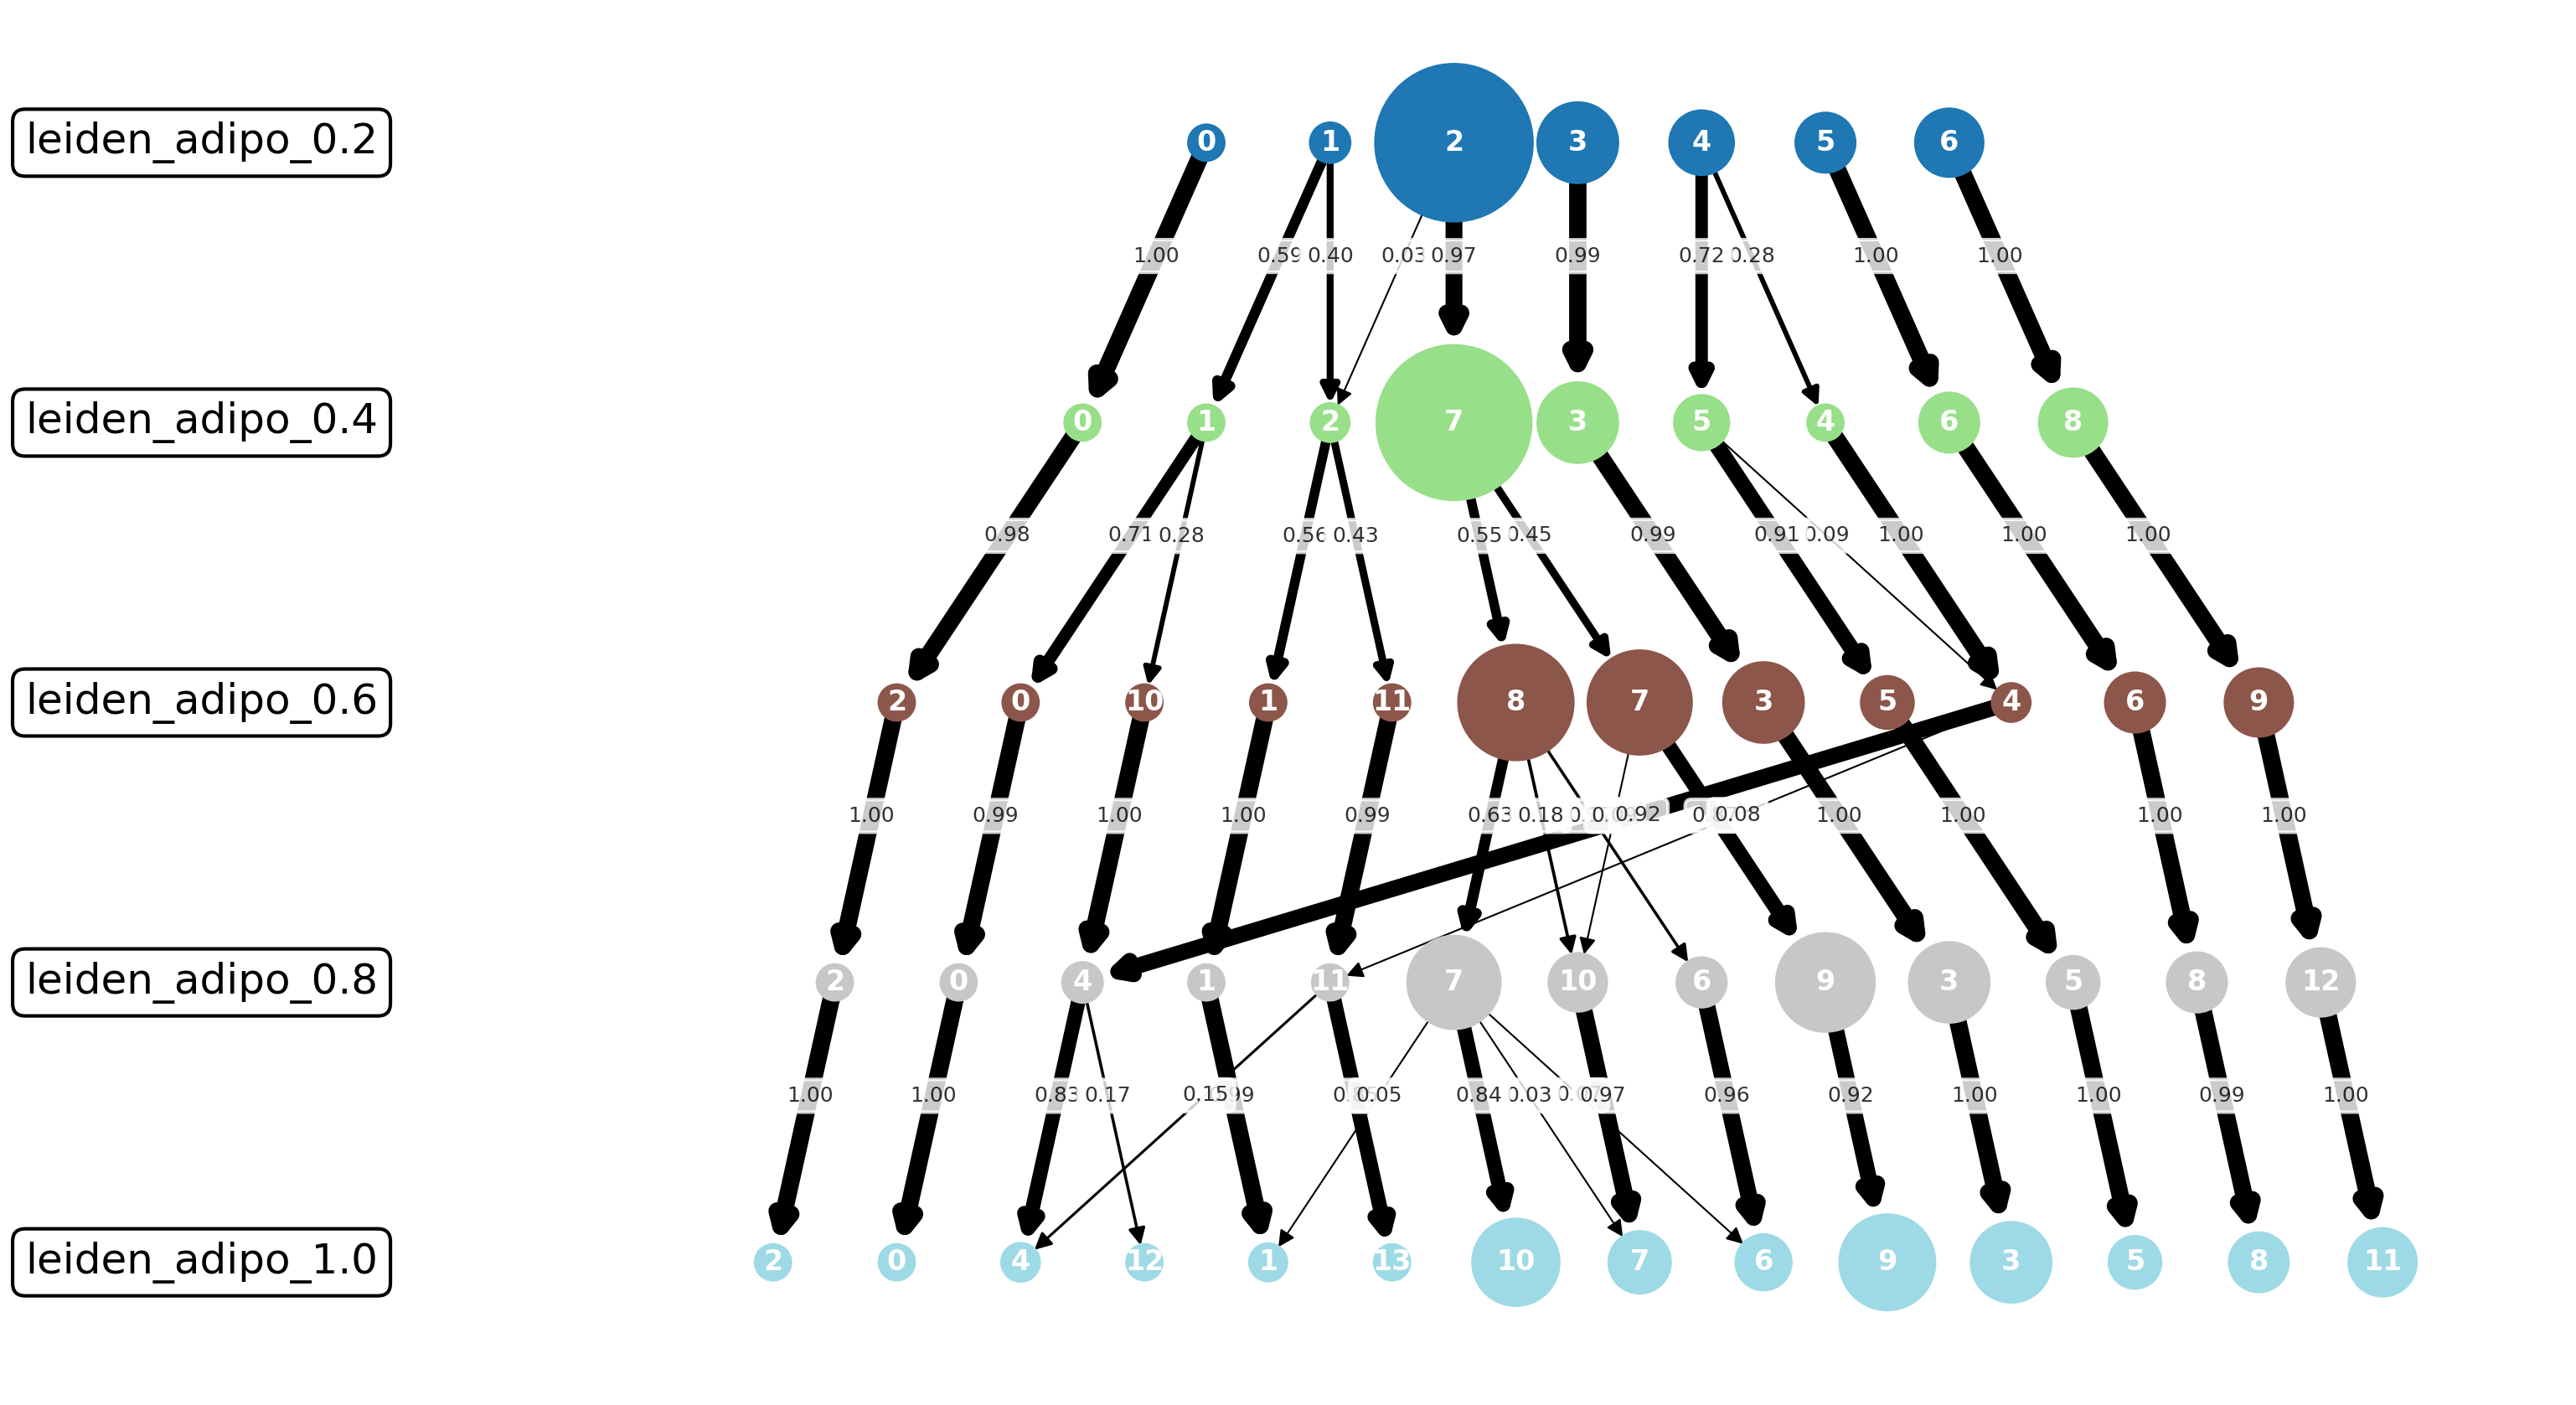

In [70]:
# Cluster(adata_adipo, f"neighbors_{INT_KEY}", CLUSTER_KEY, contam_resolutions, run_connectivity=False)

f = plot_cluster_trees(
    adata_adipo,
    [f"{CLUSTER_KEY}_{res}" for res in contam_resolutions],
    threshold=0.03,
    node_size_range=(100, 2000),
    x_spacing=2,
    y_spacing=1,
    show_fraction=True,
)

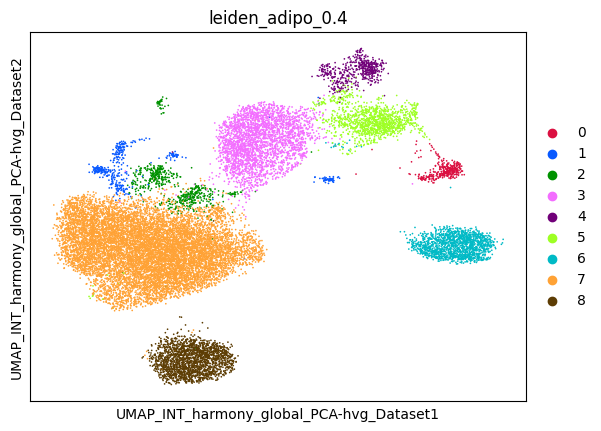

In [86]:
res = 0.4
res_key = f"{CLUSTER_KEY}_{res}"
sc.pl.embedding(adata_adipo, f"UMAP_{INT_KEY}", color=res_key,
                palette=color_gen(adata_adipo.obs[res_key].cat.categories))

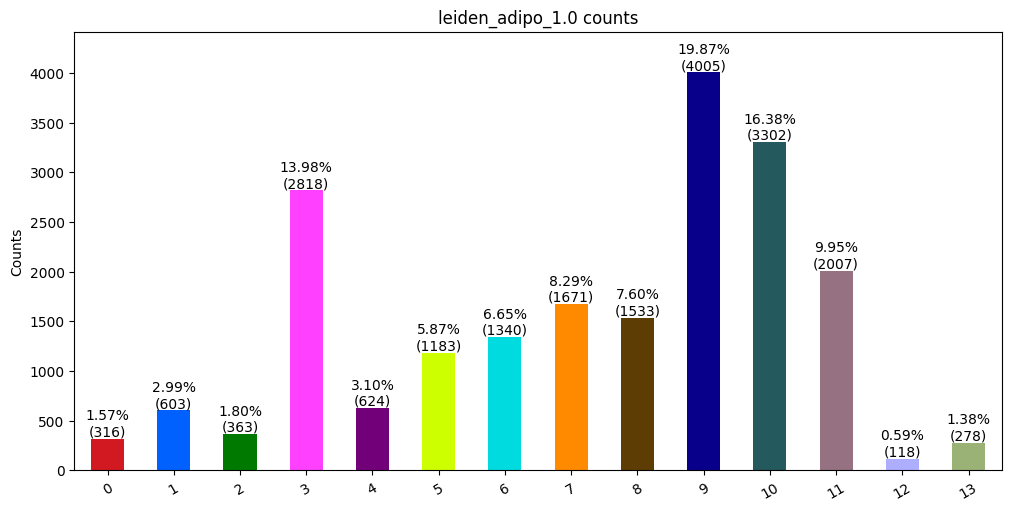

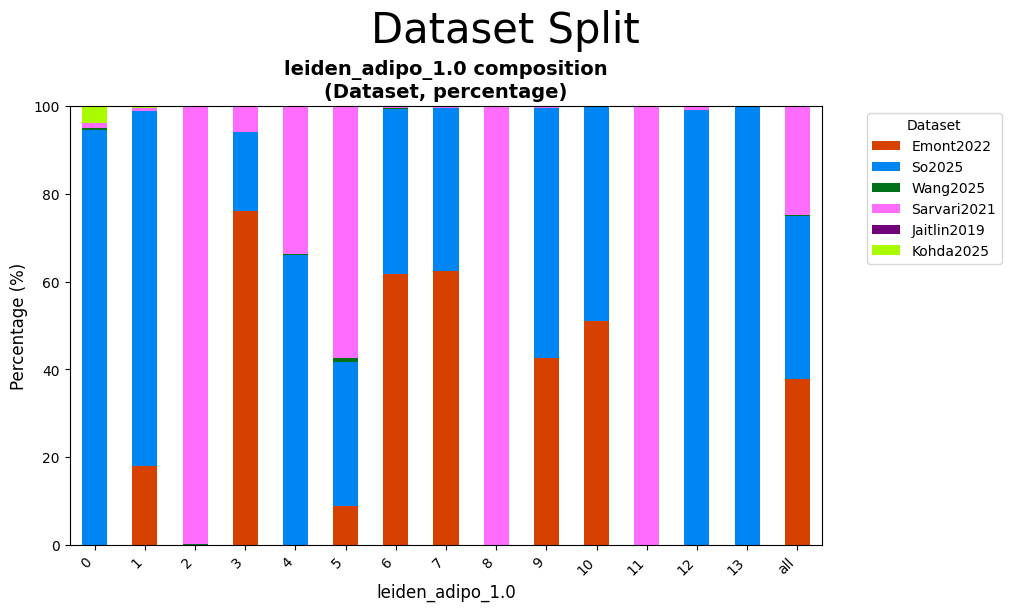

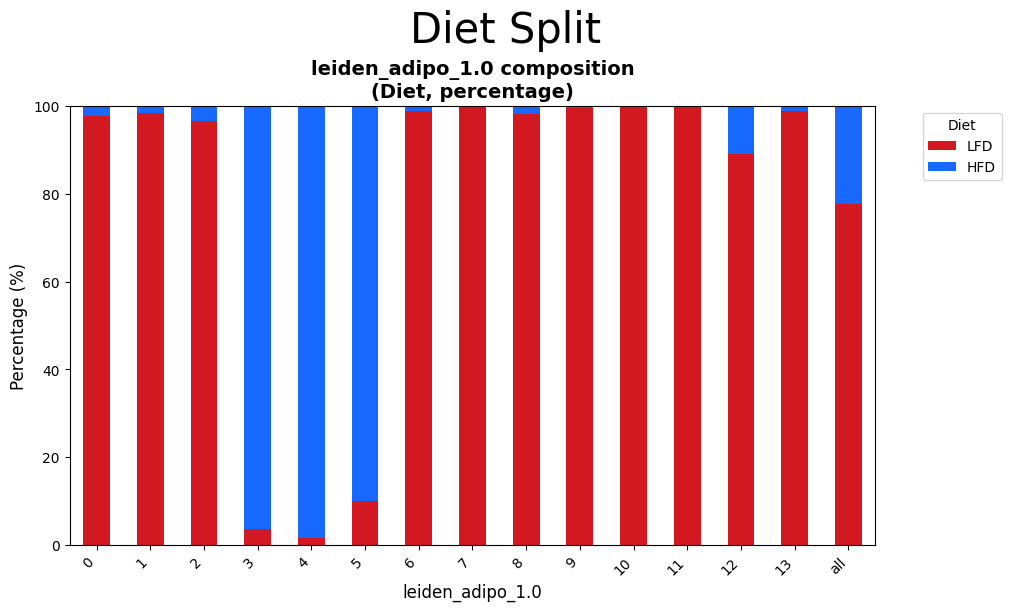

In [72]:
# counts/breakdowns
for col in adata_adipo.obs.columns:
    if CLUSTER_KEY in col:
        adata_adipo.obs[col] = adata_adipo.obs[col].astype(int).astype("category")

r, c = 1,1

# count barplots
f, ax = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
plot_cluster_counts(adata_adipo, res_key, ax=ax)

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, ax = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_stackedbarplot(adata_adipo, res_key, col, pct=True, ax=ax)
    f.suptitle(col + " Split", size=30)

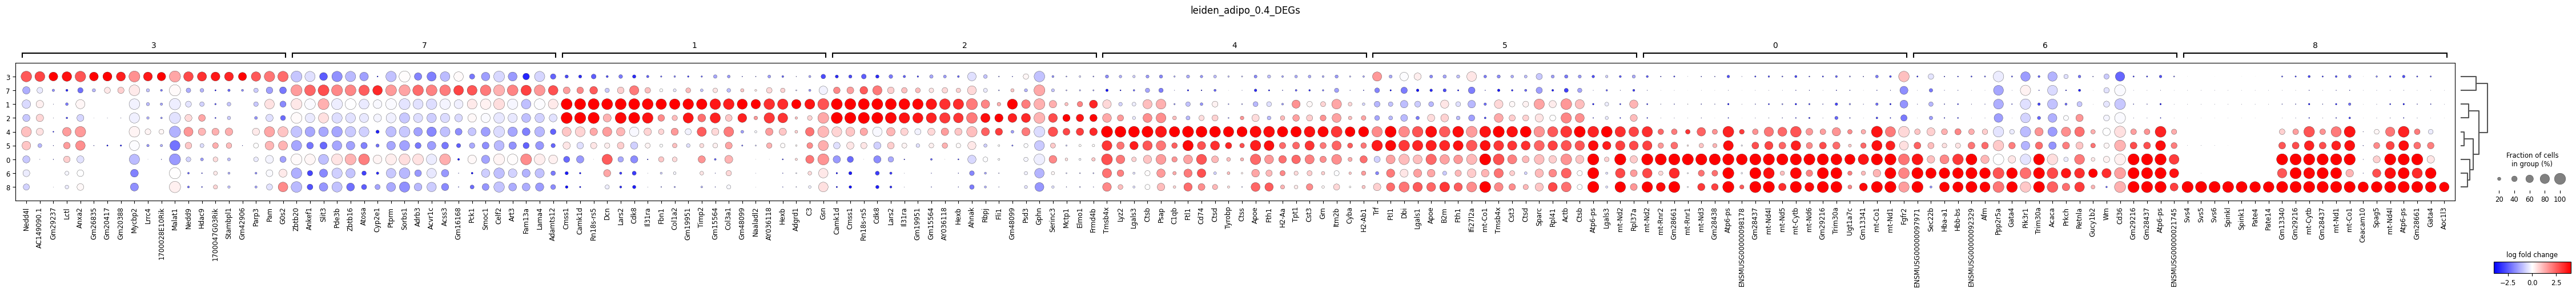

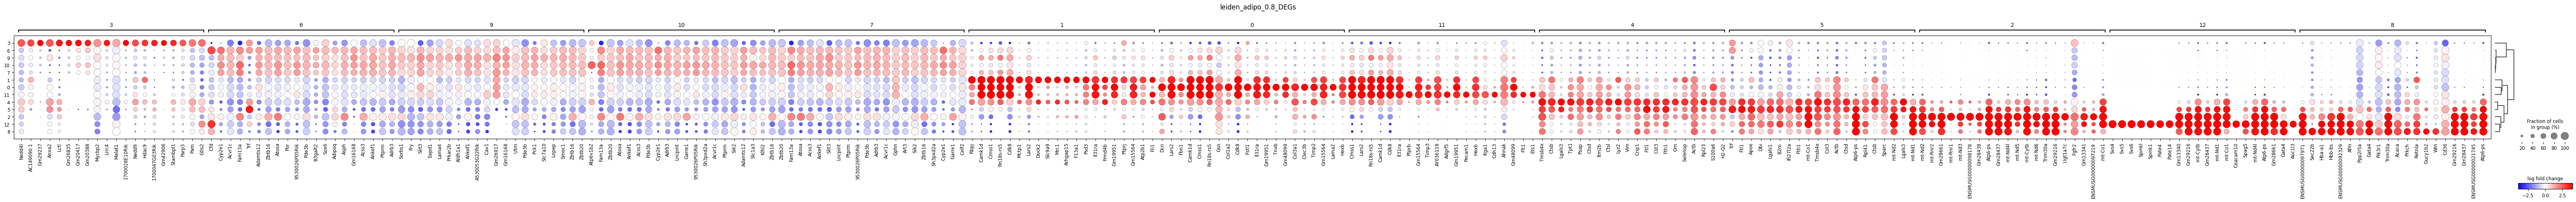

In [88]:
# original subclusters
RUN_DEG = False
SELECT_RES = [0.4, 0.8]
# clear_adata(adata_adipo, ["DEGs"])

# change to string for DEGs
for col in adata_adipo.obs.columns:
    if CLUSTER_KEY in col:
        adata_adipo.obs[col] = adata_adipo.obs[col].astype(str).astype("category")

for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(adata_adipo.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        clear_uns(adata_adipo, de_key)
        sc.tl.rank_genes_groups(
            adata_adipo,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            method="wilcoxon",
        )

    # plot DEGs
    N_genes = 20
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(
        adata_adipo, group=None, key=de_key
    ).groupby("group"):
        top_genes[group] = df["names"][:N_genes].tolist()

    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata_adipo,
        groupby=res_key,
        key=de_key,
        n_genes=20,
        # var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    # sc.pl.rank_genes_groups_heatmap(
    #     adata_adipo,
    #     key=de_key,
    #     groupby=res_key,
    #     layer="normalized",
    #     n_genes=50,
    # )

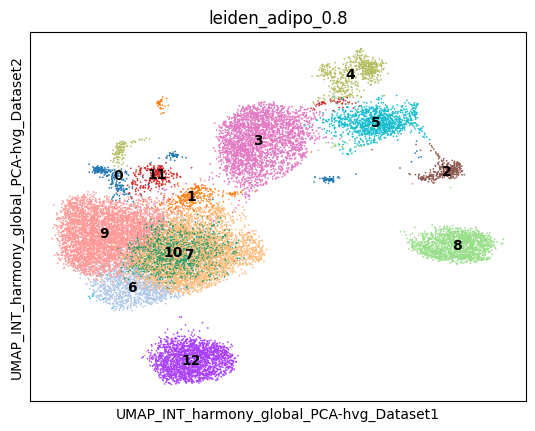

In [93]:
sc.pl.embedding(adata_adipo, f"UMAP_{INT_KEY}", color=f"{CLUSTER_KEY}_{0.8}", legend_loc="on data")

In [102]:
adata_adipo.write(SUBSETS_DIR / "adipo-uncleaned.h5ad")

In [104]:
cell_filter = ~adata_adipo.obs[f"{CLUSTER_KEY}_{0.8}"].isin(["0", "11", "12", "8", "4", "5", "2"])
adata_adipo = adata_adipo[cell_filter]
adata_adipo

View of AnnData object with n_obs × n_vars = 13727 × 22171
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'leiden_adipo_0.05', 'leiden_adipo_0.2', 'leiden_adipo_0.4', 'leiden_adipo_0.6', 'leiden_adipo_0.8', 'leiden_adipo_1.0'
    var: 'n_cells', 'n_cells_by_counts'

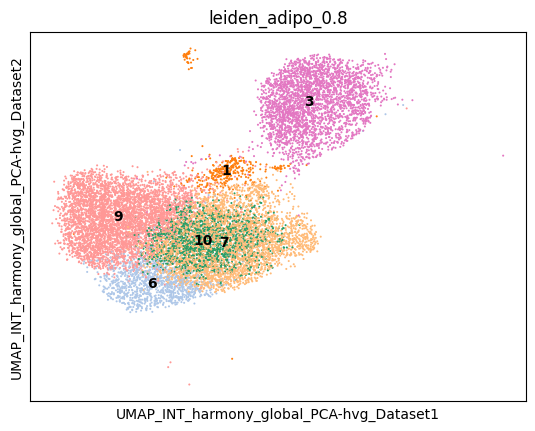

In [105]:
sc.pl.embedding(adata_adipo, f"UMAP_{INT_KEY}", color=f"{CLUSTER_KEY}_{0.8}", legend_loc="on data")